# Velocity and Efficiency Analysis using TruckScenes
This report presents the velocity and efficiency analysis conducted using the TruckScenes dataset.

The analysis focuses on how RADAR and LiDAR provide vehicle-motion information and sensor information for target-motion analysis across comparable vehicle-speed ranges.

The main research question is:

> How do RADAR, LiDAR and Camera compare in terms of velocity-related information and sensor information acquisition across comparable vehicle-speed ranges in TruckScenes?

## 1. Research Scope

This work focuses on two main aspects of sensor performance:

- **Velocity**
- **Efficiency**

### Velocity

Velocity is treated as a measurable continuous vehicle-motion metric.

Annotation-derived velocity is used as the common/reference vehicle-motion metric for later sensor comparison.

In this analysis:

- **Annotation-derived velocity** provides the common/reference vehicle-motion metric.
- **RADAR** provides direct velocity-related information.
- **LiDAR** provides spatial and temporal target information, but does not contain a direct velocity field.
- **Camera** provides visual and temporal target information, but does not contain a direct velocity field. Camera-based velocity estimation, such as optical-flow-based estimation, is not used in this analysis.

Vehicle speed ranges are used for analysis grouping and stratification.

### Efficiency

Efficiency is defined as sensor information acquisition performance and availability for target-motion analysis.

The analysis therefore compares measurable information-availability indicators for RADAR, LiDAR, and Camera, using sensor-appropriate metrics rather than treating their raw information quantities as directly equivalent.

A composite efficiency score is not used in this analysis.

## 2. Dataset and Analysis Setup

This analysis uses the TruckScenes `v1.2-mini` dataset during development. Dataset paths and the active metadata version are managed through the shared project configuration so that the same analysis workflow can later be applied to the complete TruckScenes dataset without changing the report logic.

TruckScenes provides RADAR, LiDAR, and camera observations together with object annotations, sensor calibration, ego-motion information, and timestamps. The velocity analysis in this report focuses primarily on RADAR and LiDAR. Camera data is not used to derive vehicle velocity, but is retained for later sensor-information and visibility-related analysis.


In [60]:
import pandas as pd
from src.config import VERSION, DATA_ROOT, METADATA_ROOT, SENSOR_ROOT
from src.data_io import load_json
import matplotlib.pyplot as plt
import numpy as np
from truckscenes import TruckScenes

from src.annotation_velocity import build_annotation_trajectory_df, build_annotation_pairs, add_time_differences, add_position_changes, add_reference_velocity
from src.sensor_observation import build_sensor_data_df, get_sampling_intervals, get_sampling_interval_summary, get_frequency_summary
from src.radar_velocity import build_target_radar_points_df, build_target_radar_velocity_df, build_radar_radial_df, build_radar_velocity_df
from src.lidar_velocity import build_lidar_target_states_df, build_lidar_velocity_df
from src.camera import build_camera_target_df
from src.comparison import build_velocity_comparison_df


In [2]:
sensor_df = pd.DataFrame(load_json(METADATA_ROOT / "sensor.json"))
sensor_summary = sensor_df.groupby("modality", as_index=False).agg(Number_of_Channels=("channel", "nunique"), Channels=("channel", lambda x: ", ".join(sorted(x))))

print(f"TruckScenes dataset: {VERSION}")
display(sensor_summary)

TruckScenes dataset: v1.2-mini


,modality,Number_of_Channels,Channels
0,camera,4,"CAMERA_LEFT_BACK, CAMERA_LEFT_FRONT, CAMERA_RI..."
1,imu,2,"XSENSE_CABIN, XSENSE_CHASSIS"
2,lidar,6,"LIDAR_LEFT, LIDAR_REAR, LIDAR_RIGHT, LIDAR_TOP..."
3,radar,6,"RADAR_LEFT_BACK, RADAR_LEFT_FRONT, RADAR_LEFT_..."


### 2.1 Relevant Metadata Structure

Only the metadata required by the later analysis is retained here.

| Metadata                          | Role in the analysis                                                                                           |
| --------------------------------- | -------------------------------------------------------------------------------------------------------------- |
| `sample.json`                     | Defines key samples, scene membership, and sample timestamps.                                                  |
| `sample_data.json`                | Links individual sensor observations to samples and provides sensor-observation timestamps and file locations. |
| `sensor.json`                     | Identifies sensor modality and channel.                                                                        |
| `calibrated_sensor.json`          | Provides the position and orientation of each calibrated sensor.                                               |
| `sample_annotation.json`          | Provides annotated object position and temporal links between annotations.                                     |
| `instance.json` / `category.json` | Links annotations belonging to the same physical object and identifies object category.                        |
| `ego_pose.json`                   | Provides the ego-vehicle pose required for coordinate transformations.                                         |
| `ego_motion_chassis.json`         | Provides ego-vehicle motion information where required by later sensor analysis.                               |

TruckScenes metadata timestamps used in this analysis are stored in microseconds. Therefore,

$$
t_{\mathrm{s}}=\frac{t_{\mu s}}{1{,}000{,}000}.
$$

`sample.timestamp` represents the timestamp of the annotation/key-sample reference, while `sample_data.timestamp` represents the timestamp of an individual sensor observation. These two timestamps are therefore kept distinct in the later alignment analysis.


### 2.2 Samples, Sweeps, and Vehicle Annotations

TruckScenes contains both key-sample observations and intermediate sweep observations. A `sample` represents a key point in the annotated scene timeline, while `sample_data` contains the individual sensor observations linked to that sample. Sensor files stored under `samples/` correspond to key observations, while `sweeps/` provides additional intermediate observations between key samples.

This distinction is important because annotation-derived reference velocity is based on the key-sample annotation timeline, whereas sensor-information acquisition may use the denser sequence of available sensor observations.

Object annotations are linked through

`sample_annotation.sample_token` → `sample.token`

and

`sample_annotation.instance_token` → `instance.token` → `category`.

The `prev` and `next` annotation links allow consecutive observations of the same physical object to be followed through time. For the vehicle analysis, categories beginning with `vehicle.*` are treated as target vehicles, with `vehicle.ego_trailer` excluded because it belongs to the recording vehicle rather than an independent target vehicle.


## 3. Reference Vehicle Motion and Efficiency Analysis Inputs

This section establishes the common analysis inputs used by the later sensor-specific and cross-sensor analyses.

First, vehicle motion is derived from consecutive TruckScenes object annotations. **Annotation-derived velocity is used as the common/reference vehicle-motion metric throughout the later analysis.** It is independent of RADAR, LiDAR, Camera, and ego-motion measurements.

Second, efficiency-related information is prepared for the three sensor modalities. Target-level RADAR and LiDAR point counts are retained from the annotation metadata, while sensor-observation metadata is used to identify the available RADAR, LiDAR, and Camera observations and their timestamps.

This section prepares the common reference and analysis inputs only. It does not compare sensor performance.


### 3.1 Annotation-derived Reference Velocity

A common vehicle-motion reference is required before the sensor-specific analyses are performed. In this report, vehicle motion is derived from consecutive TruckScenes object annotations rather than directly from RADAR, LiDAR, Camera, or ego-motion measurements.

**Annotation-derived velocity is the common/reference vehicle-motion metric used throughout the later analysis.** This section therefore establishes the reference motion only; it does not compare sensor performance.

Annotations belonging to the same physical object are linked through their `instance_token` and consecutive `next` relationships. Each annotation is associated with its corresponding key-sample timestamp and 3D position.

For two consecutive annotations,

$$
\Delta t=\frac{t_{end}-t_{start}}{1{,}000{,}000},
$$

where TruckScenes timestamps are stored in microseconds and \(\Delta t\) is expressed in seconds.

Position changes are calculated as

$$
\Delta x=x_{end}-x_{start},\qquad
\Delta y=y_{end}-y_{start},\qquad
\Delta z=z_{end}-z_{start}.
$$

The 2D and 3D displacements are

$$
d_{2D}=\sqrt{\Delta x^2+\Delta y^2},
$$

$$
d_{3D}=\sqrt{\Delta x^2+\Delta y^2+\Delta z^2}.
$$

The corresponding reference speeds are

$$
v_{2D}=\frac{d_{2D}}{\Delta t},\qquad
v_{3D}=\frac{d_{3D}}{\Delta t}.
$$

The 2D ground-plane speed is used as the primary vehicle-motion reference because road vehicles mainly move in the horizontal plane. The 3D speed is retained as a diagnostic measure for evaluating the influence of vertical annotation changes.


In [3]:
samples = load_json(METADATA_ROOT / "sample.json")
annotations = load_json(METADATA_ROOT / "sample_annotation.json")
instances = load_json(METADATA_ROOT / "instance.json")
categories = load_json(METADATA_ROOT / "category.json")

trajectory_df = build_annotation_trajectory_df(samples=samples, annotations=annotations, instances=instances, categories=categories)
annotation_pairs = build_annotation_pairs(trajectory_df)
annotation_pairs = add_time_differences(annotation_pairs)
annotation_pairs = add_position_changes(annotation_pairs)
velocity_df = add_reference_velocity(annotation_pairs)

vehicle_reference_df = velocity_df[
    velocity_df["category"].str.startswith("vehicle.")
    & (velocity_df["category"] != "vehicle.ego_trailer")
].copy()

vehicle_reference_df["speed_2d_kmh"] = vehicle_reference_df["speed_2d_mps"] * 3.6
vehicle_reference_df["speed_3d_kmh"] = vehicle_reference_df["speed_3d_mps"] * 3.6

In [4]:
reference_summary = pd.DataFrame({
    "Metric": [
        "Annotations",
        "Object instances",
        "Consecutive annotation pairs",
        "Median Δt (s)",
        "Maximum Δt (s)",
        "Non-positive Δt",
        "Vehicle reference intervals",
        "Vehicle instances",
        "Median 2D vehicle speed (m/s)",
        "Median 3D vehicle speed (m/s)"
    ],
    "Value": [
        len(trajectory_df),
        trajectory_df["instance_token"].nunique(),
        len(annotation_pairs),
        annotation_pairs["dt_s"].median(),
        annotation_pairs["dt_s"].max(),
        (annotation_pairs["dt_s"] <= 0).sum(),
        len(vehicle_reference_df),
        vehicle_reference_df["instance_token"].nunique(),
        vehicle_reference_df["speed_2d_mps"].median(),
        vehicle_reference_df["speed_3d_mps"].median()
    ]
})

display(reference_summary.round(3))

,Metric,Value
0,Annotations,25750.000
1,Object instances,1094.000
2,Consecutive annotation pairs,24656.000
3,Median Δt (s),0.500
4,Maximum Δt (s),12.000
5,Non-positive Δt,0.000
6,Vehicle reference intervals,15743.000
7,Vehicle instances,750.000
8,Median 2D vehicle speed (m/s),4.097
9,Median 3D vehicle speed (m/s),4.321


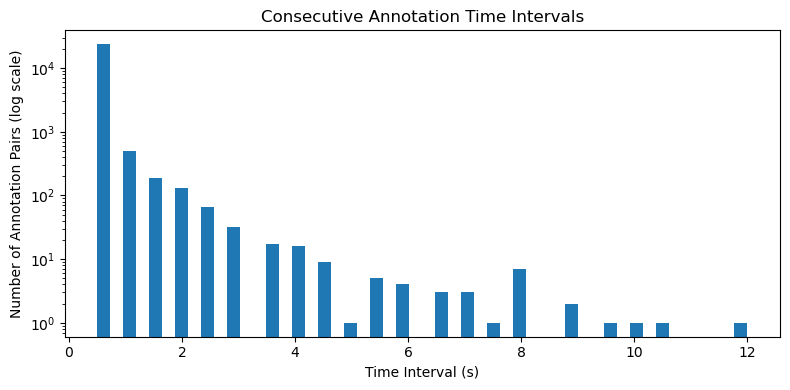

In [5]:
plt.figure(figsize=(8, 4))
plt.hist(annotation_pairs["dt_s"], bins=50)
plt.yscale("log")
plt.xlabel("Time Interval (s)")
plt.ylabel("Number of Annotation Pairs (log scale)")
plt.title("Consecutive Annotation Time Intervals")
plt.tight_layout()
plt.show()

Most consecutive annotation pairs are separated by approximately 0.5 s, indicating that the reference velocity is generally calculated over a consistent keyframe interval. No non-positive time intervals were identified, while a small number of longer gaps are present, with the maximum interval reaching approximately 12 s. The derived velocity therefore represents the average target motion between consecutive annotations rather than an instantaneous velocity measurement.

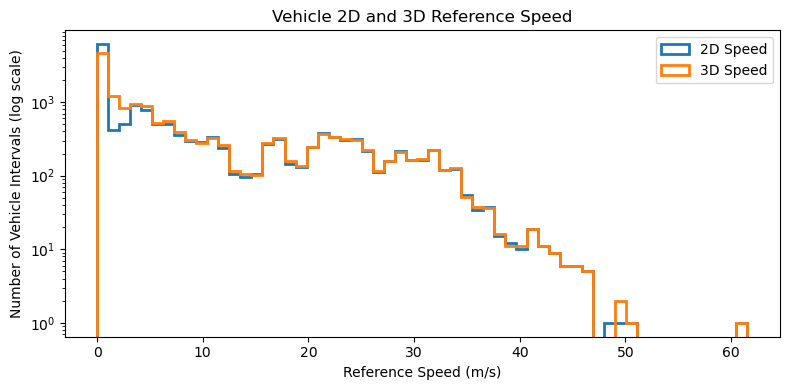

In [6]:
bins = np.linspace(0, vehicle_reference_df[["speed_2d_mps", "speed_3d_mps"]].to_numpy().max(), 60)

plt.figure(figsize=(8, 4))
plt.hist(vehicle_reference_df["speed_2d_mps"], bins=bins, histtype="step", linewidth=2, label="2D Speed")
plt.hist(vehicle_reference_df["speed_3d_mps"], bins=bins, histtype="step", linewidth=2, label="3D Speed")
plt.yscale("log")
plt.xlabel("Reference Speed (m/s)")
plt.ylabel("Number of Vehicle Intervals (log scale)")
plt.title("Vehicle 2D and 3D Reference Speed")
plt.legend()
plt.tight_layout()
plt.show()

The 2D and 3D reference-speed distributions show a similar overall pattern, with median speeds of approximately 4.10 m/s and 4.32 m/s, respectively. The relatively small difference indicates that horizontal motion accounts for most of the measured vehicle displacement. Therefore, 2D ground-plane speed is used as the primary reference vehicle-motion metric in the later analysis, while 3D speed is retained as a diagnostic measure for vertical annotation changes.


### 3.2 Efficiency-related Information Preparation

The later efficiency analysis evaluates the amount and availability of usable sensor information under comparable vehicle-motion conditions.

TruckScenes annotations provide target-associated `num_radar_pts` and `num_lidar_pts` fields. These are retained as sensor-specific measures of the amount of RADAR and LiDAR information associated with each annotated target vehicle.

Camera information is structured differently. There is no directly equivalent target-level camera point-count field in the annotation metadata. Camera efficiency is therefore prepared at the sensor-observation level using `sample_data.json`, including observation availability, channel, timestamp, and image filename. Camera-specific measures such as target visibility are evaluated later in the Camera analysis.

RADAR and LiDAR point counts are not treated as directly equivalent quantities because the two sensors provide different types of information. The final efficiency analysis therefore considers information availability, amount, and type rather than comparing raw point counts alone.


In [7]:
category_lookup = {c["token"]: c["name"] for c in categories}
instance_category = {i["token"]: category_lookup[i["category_token"]] for i in instances}

vehicle_annotation_df = pd.DataFrame([
    {
        "annotation_token": a["token"],
        "instance_token": a["instance_token"],
        "sample_token": a["sample_token"],
        "category": instance_category[a["instance_token"]],
        "num_radar_pts": a["num_radar_pts"],
        "num_lidar_pts": a["num_lidar_pts"]
    }
    for a in annotations
    if instance_category[a["instance_token"]].startswith("vehicle.")
    and instance_category[a["instance_token"]] != "vehicle.ego_trailer"
])

sensor_data_df = build_sensor_data_df()

The annotation workflow provides a common vehicle-motion reference independent of the sensor measurements. The resulting 2D ground-plane speed is used as the primary reference metric, while the 3D speed is retained for diagnostic purposes. In parallel, target-level RADAR and LiDAR point counts and observation-level RADAR, LiDAR, and Camera metadata have been prepared for the later efficiency analysis. No sensor-performance comparison is performed at this stage.

## 4. RADAR Analysis

This section examines the velocity-related information and target-associated information provided by TruckScenes RADAR.

Two aspects are considered. First, the direct RADAR velocity-related measurements are analysed at return and target level. Second, RADAR information acquisition is evaluated using target availability, associated return count, and sensor support.

The annotation-derived 2D ground-plane speed established in Section 3 is used to define comparable reference-speed ranges. These ranges provide common vehicle-motion conditions for the analysis.

A secondary analysis evaluates whether the available RADAR velocity information can support a stable 2D target-velocity estimate. Cross-sensor comparison is performed later.

### 4.1 RADAR Information Type and Target Association

TruckScenes RADAR provides point-level spatial coordinates and relative-velocity components (`vrel_x`, `vrel_y`, and `vrel_z`). These measurements contain direct velocity-related information, but they are not directly equivalent to the absolute target velocity represented by the annotation-derived reference.

Keyframe RADAR observations are therefore associated with annotated target vehicles to construct target-level information measures. Target-associated return count and relative-velocity summaries are used first to describe RADAR information acquisition. A separate ego-compensated 2D velocity reconstruction is evaluated later as a velocity outcome.

In [8]:
radar_observation_df = sensor_data_df[sensor_data_df["Modality"] == "RADAR"].copy()
keyframe_radar = radar_observation_df[radar_observation_df["Is Key Frame"]].copy()

target_radar_points_df = build_target_radar_points_df(keyframe_radar)
target_radar_df = build_target_radar_velocity_df(target_radar_points_df)

RADAR target association is performed using keyframe observations. Annotation boxes are transformed into each RADAR sensor frame and returns located inside the corresponding target boxes are retained.

The keyframe observations are closely aligned with the linked annotation samples, with a median absolute timestamp offset of approximately 5.44 ms and a maximum of approximately 55.84 ms. The association workflow was also validated against the annotation `num_radar_pts` metadata for a six-sensor keyframe sample, producing exact agreement for all 69 vehicle annotations.

### 4.2 Overall RADAR Information Acquisition

The target-level RADAR observations show that the amount of information available for individual vehicles is highly variable. Many targets are supported by only a small number of RADAR returns, while a smaller number receive substantially more measurements.

The relative-velocity magnitude summarises the direct velocity-related information contained in the target-associated RADAR returns. It is retained as an information characteristic and is not interpreted as the absolute target speed.

In [9]:
radar_summary = pd.DataFrame({
    "Metric": ["RADAR observations", "Keyframe RADAR observations", "Target-associated RADAR returns", "Target observations", "Target vehicles", "Median returns per target", "Single-return observations"],
    "Value": [len(radar_observation_df), len(keyframe_radar), len(target_radar_points_df), len(target_radar_df), target_radar_df["instance_token"].nunique(), target_radar_df["radar_return_count"].median(), (target_radar_df["radar_return_count"] == 1).sum()]
})

display(radar_summary)

,Metric,Value
0,RADAR observations,23439.0
1,Keyframe RADAR observations,2400.0
2,Target-associated RADAR returns,52184.0
3,Target observations,9588.0
4,Target vehicles,639.0
5,Median returns per target,3.0
6,Single-return observations,2845.0


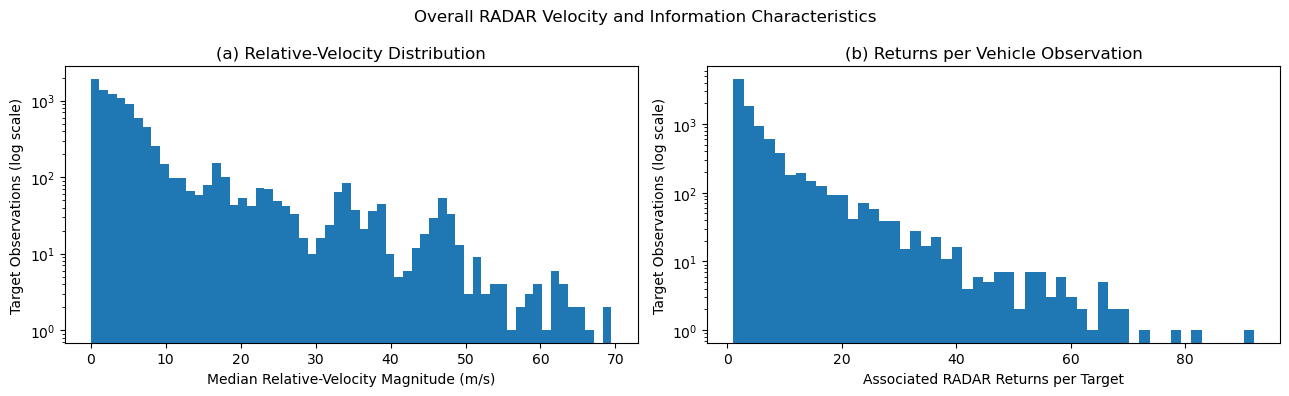

In [10]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].hist(target_radar_df["median_vrel_magnitude"], bins=60)
axes[0].set_yscale("log")
axes[0].set_xlabel("Median Relative-Velocity Magnitude (m/s)")
axes[0].set_ylabel("Target Observations (log scale)")
axes[0].set_title("(a) Relative-Velocity Distribution")

axes[1].hist(target_radar_df["radar_return_count"], bins=50)
axes[1].set_yscale("log")
axes[1].set_xlabel("Associated RADAR Returns per Target")
axes[1].set_ylabel("Target Observations (log scale)")
axes[1].set_title("(b) Returns per Vehicle Observation")

fig.suptitle("Overall RADAR Velocity and Information Characteristics")
plt.tight_layout()
plt.show()

The two distributions describe complementary characteristics of target-level RADAR information. Relative-velocity measurements are strongly right-skewed, with most target observations containing relatively small velocity magnitudes and a smaller number extending to substantially larger values. Target-associated information amount is similarly uneven: most vehicle observations contain only a small number of RADAR returns, with a median of three returns per target. RADAR therefore provides direct relative-motion information, but the amount of information available for individual targets is generally sparse and variable.

### 4.3 Sensor-level RADAR Characteristics

In [11]:
radar_point_df = target_radar_points_df.copy()
radar_point_df["vrel_magnitude"] = np.sqrt(radar_point_df["vrel_x"]**2 + radar_point_df["vrel_y"]**2 + radar_point_df["vrel_z"]**2)

radar_sensor_target_df = radar_point_df.groupby(["sensor", "annotation_token"], as_index=False).agg(
    radar_return_count=("vrel_magnitude", "size"),
    median_vrel_magnitude=("vrel_magnitude", "median")
)

radar_sensors = sorted(radar_sensor_target_df["sensor"].unique())

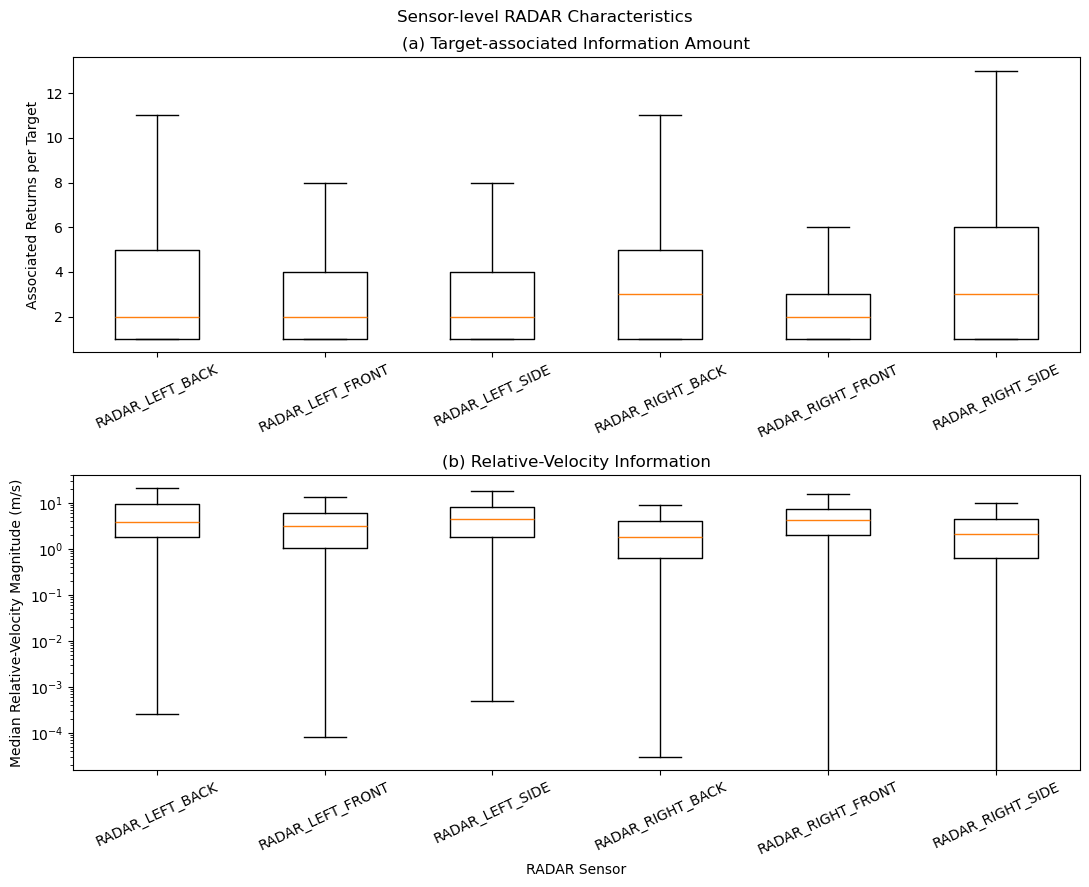

In [12]:
fig, axes = plt.subplots(2, 1, figsize=(11, 9))

return_data = [radar_sensor_target_df.loc[radar_sensor_target_df["sensor"] == sensor, "radar_return_count"] for sensor in radar_sensors]
axes[0].boxplot(return_data, labels=radar_sensors, showfliers=False)
axes[0].set_ylabel("Associated Returns per Target")
axes[0].set_title("(a) Target-associated Information Amount")
axes[0].tick_params(axis="x", rotation=25)

velocity_data = [radar_sensor_target_df.loc[radar_sensor_target_df["sensor"] == sensor, "median_vrel_magnitude"] for sensor in radar_sensors]
axes[1].boxplot(velocity_data, labels=radar_sensors, showfliers=False)
axes[1].set_yscale("log")
axes[1].set_xlabel("RADAR Sensor")
axes[1].set_ylabel("Median Relative-Velocity Magnitude (m/s)")
axes[1].set_title("(b) Relative-Velocity Information")
axes[1].tick_params(axis="x", rotation=25)

fig.suptitle("Sensor-level RADAR Characteristics")
plt.tight_layout()
plt.show()

The six RADAR channels show differences in both target-associated information amount and relative-velocity characteristics. Most sensors provide a median of approximately two returns per target, while `RADAR_RIGHT_BACK` and `RADAR_RIGHT_SIDE` show slightly higher typical return counts. Relative-velocity distributions also differ between sensor channels. These variations should not be interpreted directly as differences in sensor quality because sensor orientation, field of view, target position, and line-of-sight geometry also affect the observed information.

### 4.4 RADAR Information Stratified by Reference Speed

To examine whether RADAR information acquisition differs across the range of target motion represented in the dataset, the target-level results are stratified using the common annotation-derived reference-speed ranges defined earlier.

These ranges are used as analytical groups rather than experimental conditions. Differences between ranges are therefore interpreted as variation associated with the observed reference-speed groups, not as evidence that vehicle speed directly causes changes in RADAR information acquisition.

In [13]:
radar_reference_df = target_radar_df.merge(
    vehicle_reference_df[["start_annotation_token", "speed_2d_mps"]],
    left_on="annotation_token",
    right_on="start_annotation_token",
    how="left",
    validate="one_to_one"
)

matched_radar_df = radar_reference_df.dropna(subset=["speed_2d_mps"]).copy()

print("RADAR target observations:", len(target_radar_df))
print("Matched reference intervals:", len(matched_radar_df))
print("Reference match rate (%):", round(len(matched_radar_df) / len(target_radar_df) * 100, 2))

RADAR target observations: 9588
Matched reference intervals: 9280
Reference match rate (%): 96.79


Of the 9,588 target-level RADAR observations, 9,280 (96.79%) can be linked to an annotation-derived reference-velocity interval. The remaining 308 observations correspond to the final annotation of an object trajectory, where no subsequent annotation is available to define a reference-velocity interval.

In [14]:
speed_bins = [0, 10, 20, 30, 40, 50, 60, 70, 80, 90, 100, 110, np.inf]
speed_labels = ["0–<10", "10–<20", "20–<30", "30–<40", "40–<50", "50–<60", "60–<70", "70–<80", "80–<90", "90–<100", "100–<110", "≥110"]

reference_speed_df = vehicle_reference_df.copy()
reference_speed_df["speed_range_kmh"] = pd.cut(reference_speed_df["speed_2d_kmh"], bins=speed_bins, labels=speed_labels, right=False, include_lowest=True)

radar_speed_df = matched_radar_df.copy()
radar_speed_df["speed_2d_kmh"] = radar_speed_df["speed_2d_mps"] * 3.6
radar_speed_df["speed_range_kmh"] = pd.cut(radar_speed_df["speed_2d_kmh"], bins=speed_bins, labels=speed_labels, right=False, include_lowest=True)

In [15]:
reference_counts = (reference_speed_df.groupby("speed_range_kmh", observed=False).size().rename("Reference Intervals"))
radar_counts = (radar_speed_df.groupby("speed_range_kmh", observed=False).size().rename("RADAR Observations"))
radar_speed_summary = pd.concat([reference_counts, radar_counts], axis=1)
radar_speed_summary["RADAR Availability (%)"] = (radar_speed_summary["RADAR Observations"] / radar_speed_summary["Reference Intervals"] * 100)

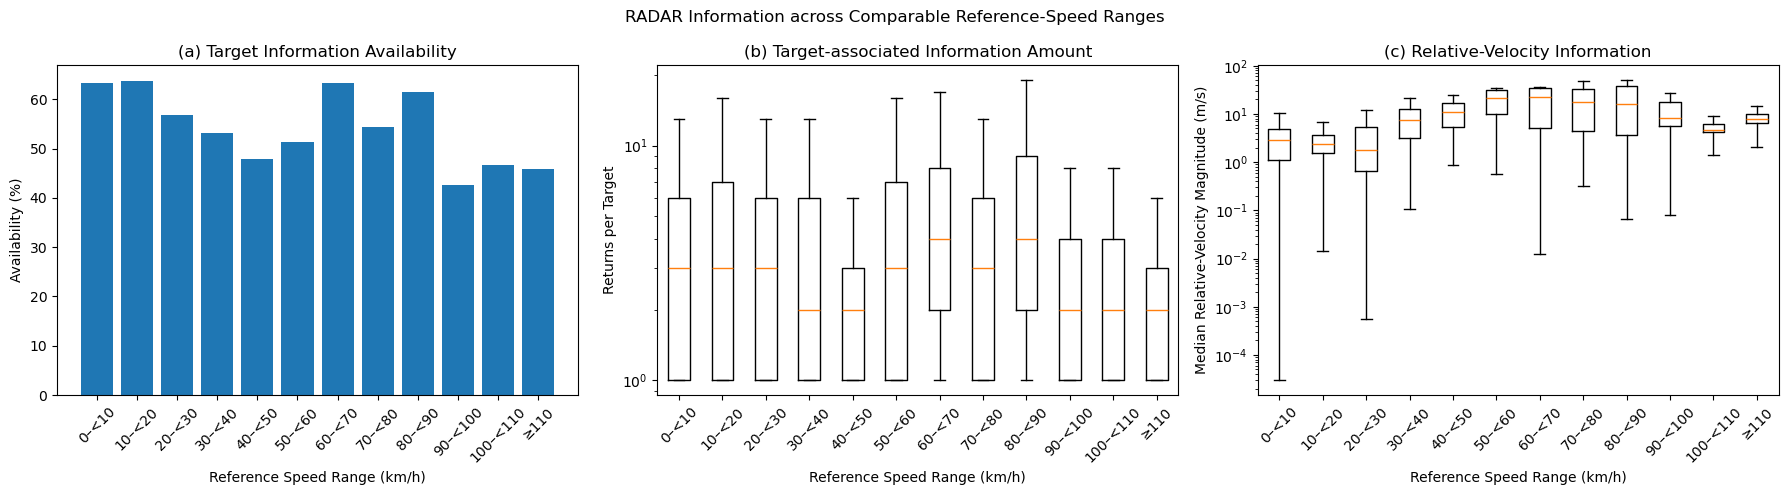

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

speed_categories = radar_speed_df["speed_range_kmh"].cat.categories
x_labels = [str(x) for x in speed_categories]
plot_data = radar_speed_summary.reset_index()

axes[0].bar(x_labels, plot_data["RADAR Availability (%)"])
axes[0].set_ylabel("Availability (%)")
axes[0].set_title("(a) Target Information Availability")

return_data = [
    radar_speed_df.loc[radar_speed_df["speed_range_kmh"] == speed_range, "radar_return_count"].dropna()
    for speed_range in speed_categories
]

axes[1].boxplot(return_data, labels=x_labels, showfliers=False)
axes[1].set_yscale("log")
axes[1].set_ylabel("Returns per Target")
axes[1].set_title("(b) Target-associated Information Amount")

velocity_data = [
    radar_speed_df.loc[radar_speed_df["speed_range_kmh"] == speed_range, "median_vrel_magnitude"].dropna()
    for speed_range in speed_categories
]

axes[2].boxplot(velocity_data, labels=x_labels, showfliers=False)
axes[2].set_yscale("log")
axes[2].set_ylabel("Median Relative-Velocity Magnitude (m/s)")
axes[2].set_title("(c) Relative-Velocity Information")

for ax in axes:
    ax.set_xlabel("Reference Speed Range (km/h)")
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("RADAR Information across Comparable Reference-Speed Ranges")
plt.tight_layout()
plt.show()

Across the reference-speed ranges, RADAR target-information availability and the amount of target-associated information vary substantially, but neither follows a simple monotonic pattern. This indicates that the observed information acquisition cannot be explained by reference speed alone.

The direct relative-velocity information also varies across the reference-speed groups and does not correspond one-to-one with annotation-derived absolute speed, consistent with the relative and line-of-sight nature of the original RADAR measurements.

### 4.5 RADAR-derived 2D Velocity Outcome

The previous sections describe the amount and type of information acquired by RADAR. This section evaluates velocity as a separate measurable outcome.

The target-associated RADAR returns are converted into ego-compensated radial-velocity constraints and combined across consecutive annotation intervals to reconstruct 2D target velocity. Only full-rank solutions are produced, and estimates satisfying the validated numerical-stability criterion are treated as stable velocity outcomes.

The resulting velocity estimates are compared with the annotation-derived 2D reference velocity using two complementary measures: the availability of stable velocity estimates and their absolute speed error.

In [17]:
RADAR_CONDITION_LIMIT = 20

radar_radial_df = build_radar_radial_df(target_radar_points_df)
radar_velocity_df = build_radar_velocity_df(radar_radial_df, vehicle_reference_df, condition_limit=RADAR_CONDITION_LIMIT)

radar_stable_velocity_df = radar_velocity_df[radar_velocity_df["is_stable_2d"]].merge(
    vehicle_reference_df[["start_annotation_token", "end_annotation_token", "speed_2d_mps"]],
    on=["start_annotation_token", "end_annotation_token"],
    how="inner"
).copy()

radar_stable_velocity_df["radar_speed_2d_abs_error_mps"] = (radar_stable_velocity_df["radar_speed_2d_mps"] - radar_stable_velocity_df["speed_2d_mps"]).abs()

In [18]:
radar_velocity_summary = pd.DataFrame({
    "Metric": ["Reference intervals", "Full-rank RADAR velocity intervals", "Stable RADAR velocity intervals", "Raw velocity availability (%)", "Stable velocity availability (%)", "Median absolute speed error (m/s)", "75th percentile absolute error (m/s)"],
    "Value": [
        len(vehicle_reference_df),
        len(radar_velocity_df),
        len(radar_stable_velocity_df),
        len(radar_velocity_df) / len(vehicle_reference_df) * 100,
        len(radar_stable_velocity_df) / len(vehicle_reference_df) * 100,
        radar_stable_velocity_df["radar_speed_2d_abs_error_mps"].median(),
        radar_stable_velocity_df["radar_speed_2d_abs_error_mps"].quantile(0.75)
    ]
})

display(radar_velocity_summary.round(3))

,Metric,Value
0,Reference intervals,15743.000
1,Full-rank RADAR velocity intervals,7706.000
2,Stable RADAR velocity intervals,3016.000
3,Raw velocity availability (%),48.949
4,Stable velocity availability (%),19.158
5,Median absolute speed error (m/s),0.277
6,75th percentile absolute error (m/s),1.208


Of the 15,743 reference vehicle intervals, 7,706 contain sufficient RADAR constraints for a full-rank 2D reconstruction. After applying the condition-number threshold of 20, 3,016 intervals remain numerically stable, corresponding to 19.16% of the reference intervals.

For these stable estimates, the median absolute speed difference from the annotation-derived reference is approximately 0.277 m/s, while the 75th percentile is approximately 1.21 m/s. The substantially larger mean and maximum errors observed in the original distribution indicate a long error tail, so robust summary statistics are used for interpretation.

In [19]:
radar_stable_velocity_df["speed_2d_kmh"] = radar_stable_velocity_df["speed_2d_mps"] * 3.6
radar_stable_velocity_df["speed_range_kmh"] = pd.cut(radar_stable_velocity_df["speed_2d_kmh"], bins=speed_bins, labels=speed_labels, right=False, include_lowest=True)

stable_speed_summary = radar_stable_velocity_df.groupby("speed_range_kmh", observed=False).agg(
    Stable_Intervals=("radar_speed_2d_mps", "size"),
    Median_Abs_Error=("radar_speed_2d_abs_error_mps", "median"),
    P75_Abs_Error=("radar_speed_2d_abs_error_mps", lambda x: x.quantile(0.75))
)

stable_speed_summary = pd.concat([reference_counts, stable_speed_summary], axis=1)
stable_speed_summary["Stable Availability (%)"] = stable_speed_summary["Stable_Intervals"] / stable_speed_summary["Reference Intervals"] * 100

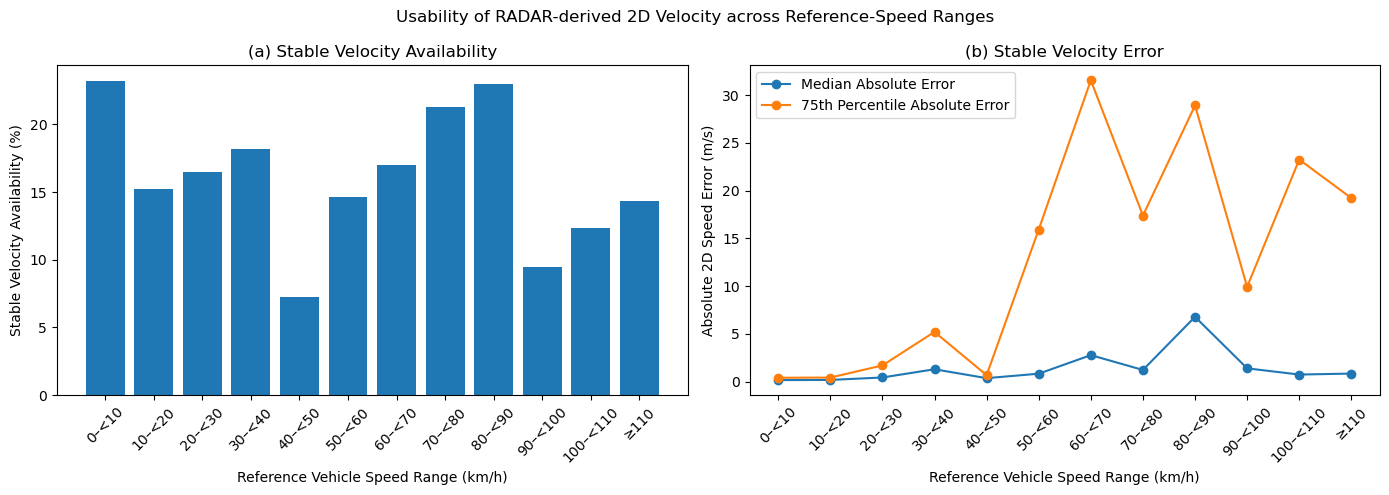

In [20]:
plot_data = stable_speed_summary.reset_index()
x = np.arange(len(plot_data))
x_labels = plot_data["speed_range_kmh"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# (a) Stable availability
axes[0].bar(x_labels, plot_data["Stable Availability (%)"])
axes[0].set_xlabel("Reference Vehicle Speed Range (km/h)")
axes[0].set_ylabel("Stable Velocity Availability (%)")
axes[0].set_title("(a) Stable Velocity Availability")
axes[0].tick_params(axis="x", rotation=45)

# (b) Speed error
axes[1].plot(x, plot_data["Median_Abs_Error"], marker="o", label="Median Absolute Error")
axes[1].plot(x, plot_data["P75_Abs_Error"], marker="o", label="75th Percentile Absolute Error")
axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, rotation=45)
axes[1].set_xlabel("Reference Vehicle Speed Range (km/h)")
axes[1].set_ylabel("Absolute 2D Speed Error (m/s)")
axes[1].set_title("(b) Stable Velocity Error")
axes[1].legend()

fig.suptitle("Usability of RADAR-derived 2D Velocity across Reference-Speed Ranges")
plt.tight_layout()
plt.show()

Stable 2D velocity availability varies substantially across the reference-speed ranges and is considerably lower than the target-information availability reported in Section 4.4. The presence of target-associated RADAR returns therefore does not necessarily provide sufficient geometric information for a stable Cartesian velocity reconstruction.

For intervals where stable reconstruction is possible, the RADAR-derived 2D speed can be compared directly with the annotation-derived reference. Median and 75th-percentile absolute errors vary across the reference-speed groups, indicating that velocity accuracy is also not uniform across the dataset.

These results separate two aspects of RADAR performance: information acquisition determines whether sufficient usable RADAR information is available, while the reconstructed velocity and its error represent the resulting velocity outcome. The reference-speed ranges are used only to stratify these outcomes and are not treated as causal conditions.

### 4.6 Summary

TruckScenes RADAR provides direct point-level relative-velocity information together with spatial target returns. After target association, these measurements provide two distinct forms of evidence for the current analysis: information-acquisition measures and a derived vehicle-velocity outcome.

RADAR information acquisition is characterised by target-information availability, the amount of target-associated returns, and the availability of relative-velocity information. Across the annotation-derived reference-speed ranges, target-information availability varies from approximately 43% to 64%, while the typical target is supported by approximately two to four RADAR returns. These measures vary substantially across the speed groups but do not follow a simple monotonic relationship with reference speed.

A separate ego-compensated reconstruction combines RADAR radial-velocity constraints to estimate 2D target velocity. Of the 15,743 annotation-derived reference intervals, 3,016 provide sufficient and numerically stable RADAR information for reconstruction, corresponding to a stable velocity availability of 19.16%.

For the stable estimates, the median absolute difference from the annotation-derived 2D reference speed is 0.277 m/s. Error and stable-velocity availability also vary across the reference-speed groups, showing that successful target association does not necessarily imply that sufficient geometric information is available for a stable velocity estimate.

The RADAR results therefore distinguish information acquisition from velocity performance. Information availability describes whether useful RADAR measurements are obtained, while stable-velocity availability and reconstruction error describe the resulting velocity outcome. The reference-speed ranges are used to stratify these results rather than as causal experimental conditions.

## 5. LiDAR Motion Information

This section examines the motion-related and target-associated information provided by TruckScenes LiDAR.

Unlike RADAR, TruckScenes LiDAR does not provide a direct velocity field. LiDAR is therefore treated as providing spatial and temporal target information that can support vehicle-motion analysis, rather than as an independent vehicle-velocity sensor.

The analysis focuses on three aspects:

- target-associated LiDAR point support,
- variation in LiDAR information under comparable reference-speed conditions,
- sensor observation availability and temporal behaviour.

The annotation-derived 2D ground-plane speed established in Section 3 remains the common vehicle-motion reference used to define comparable speed conditions.

### 5.1 LiDAR Information Type and Validation

TruckScenes LiDAR points contain spatial coordinates and point-level measurement information, including `x`, `y`, `z`, `intensity`, and timestamp information. No direct velocity field is present.

LiDAR therefore contributes spatial and temporal observations of target vehicles rather than a direct sensor-provided vehicle-velocity measurement. However, target motion can be estimated later from consecutive LiDAR-derived target positions.

The target-association workflow was examined in the earlier LiDAR validation notebook. For one validation annotation, direct point-in-box counting across the six LiDAR sensors produced 519 raw points, while the corresponding annotation metadata reported `num_lidar_pts = 430`.

The six LiDAR keyframe observations were also found to be slightly asynchronous relative to the linked annotation sample. Across the 2,400 LiDAR keyframe observations, the median absolute timestamp offset was approximately 18.96 ms and the maximum was approximately 49.54 ms. Point-level timestamps further showed that individual LiDAR scans span several tens of milliseconds around the annotation sample time.

Because a single static annotation box applied to all raw LiDAR points does not exactly reproduce the dataset-provided target-point count, direct raw point-in-box counting is not used as the primary information-amount metric in this report.

Instead, the dataset-provided `num_lidar_pts` field is retained as the target-associated LiDAR point-support measure.

### 5.2 Overall LiDAR Information Acquisition

Target-level LiDAR information is represented using the dataset-provided `num_lidar_pts` value associated with each annotated target vehicle.

Each row of `target_lidar_df` represents one target vehicle at one annotation keyframe.

The LiDAR point count is interpreted as the amount of target-associated spatial information available for that observation. It is used as an information-acquisition metric and is not interpreted as a direct vehicle-velocity measurement. LiDAR-derived velocity is evaluated separately later using consecutive target states derived from raw LiDAR observations.

In [21]:
target_lidar_df = vehicle_annotation_df[
    ["annotation_token", "instance_token", "sample_token", "category", "num_lidar_pts"]
].rename(columns={"num_lidar_pts": "lidar_point_count"}).copy()

target_lidar_df["has_lidar_information"] = target_lidar_df["lidar_point_count"] > 0

lidar_summary = pd.DataFrame({
    "Metric": [
        "Target vehicle observations",
        "Unique target vehicles",
        "Observations with LiDAR information",
        "Target information availability (%)",
        "Median LiDAR points per target",
        "75th percentile LiDAR points per target",
    ],
    "Value": [
        len(target_lidar_df),
        target_lidar_df["instance_token"].nunique(),
        target_lidar_df["has_lidar_information"].sum(),
        target_lidar_df["has_lidar_information"].mean() * 100,
        target_lidar_df["lidar_point_count"].median(),
        target_lidar_df["lidar_point_count"].quantile(0.75),
    ],
})

display(lidar_summary.round(2))

,Metric,Value
0,Target vehicle observations,16501.0
1,Unique target vehicles,758.0
2,Observations with LiDAR information,16501.0
3,Target information availability (%),100.0
4,Median LiDAR points per target,41.0
5,75th percentile LiDAR points per target,250.0


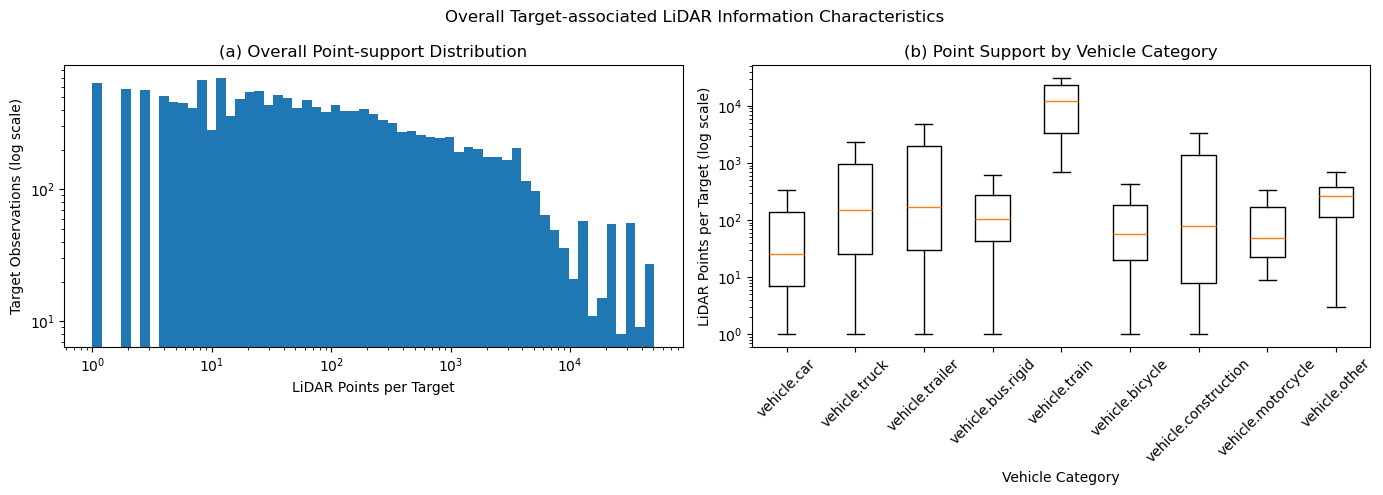

In [22]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

positive_lidar_points = target_lidar_df.loc[target_lidar_df["lidar_point_count"] > 0, "lidar_point_count"]
point_bins = np.logspace(
    np.log10(positive_lidar_points.min()),
    np.log10(positive_lidar_points.max()),
    60,
)

axes[0].hist(positive_lidar_points, bins=point_bins)
axes[0].set_xscale("log")
axes[0].set_yscale("log")
axes[0].set_xlabel("LiDAR Points per Target")
axes[0].set_ylabel("Target Observations (log scale)")
axes[0].set_title("(a) Overall Point-support Distribution")

category_counts = target_lidar_df["category"].value_counts()
vehicle_categories = category_counts.index.tolist()

category_data = [target_lidar_df.loc[target_lidar_df["category"] == category, "lidar_point_count"] for category in vehicle_categories]

axes[1].boxplot(category_data, labels=vehicle_categories, showfliers=False)
axes[1].set_yscale("log")
axes[1].set_xlabel("Vehicle Category")
axes[1].set_ylabel("LiDAR Points per Target (log scale)")
axes[1].set_title("(b) Point Support by Vehicle Category")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("Overall Target-associated LiDAR Information Characteristics")
plt.tight_layout()
plt.show()

The overall distribution shows that target-associated LiDAR point support spans several orders of magnitude and is strongly right-skewed. Most target observations contain relatively modest point counts, while a smaller number contain several thousand or even tens of thousands of points. This large variation confirms that a single mean value would not adequately describe typical LiDAR target support.

The category comparison shows that target type is also associated with substantial differences in LiDAR point support. `vehicle.train` observations contain markedly higher point counts than the other vehicle categories, while trailers, trucks, buses, and other larger vehicle types generally show higher typical support than cars, bicycles, and motorcycles. Several categories also show wide within-category distributions.

These differences indicate that target-associated LiDAR information is influenced by factors beyond vehicle motion, including physical size, visible surface area, target geometry, distance, orientation, and occlusion. The category comparison therefore provides important context for interpreting later results stratified by reference speed: variation in LiDAR point support should not be attributed to reference speed alone.

For this reason, `lidar_point_count` is treated as an information-acquisition measure describing the amount of target-associated LiDAR information available for each observation. It is not treated as a complete measure of sensor efficiency or as a direct vehicle-velocity measurement.

### 5.3 LiDAR Information Stratified by Reference Speed

Each target-level LiDAR observation is linked to the annotation-derived reference-velocity interval beginning at the same annotation.

Only observations with a valid following annotation can therefore be assigned a reference speed.

The same reference-speed ranges used in the RADAR analysis are retained so that LiDAR information acquisition can be examined using a consistent stratification and later compared across sensors.

Two questions are considered:

1. How many LiDAR-supported target observations are available in each reference-speed range?

2. How does the amount of target-associated LiDAR information vary across those ranges?

In [23]:
lidar_reference_df = target_lidar_df.merge(
    vehicle_reference_df[["start_annotation_token", "speed_2d_mps"]],
    left_on="annotation_token",
    right_on="start_annotation_token",
    how="left",
    validate="one_to_one",
)

matched_lidar_df = lidar_reference_df.dropna(subset=["speed_2d_mps"]).copy()

print("LiDAR target observations:", len(target_lidar_df))
print("Matched reference intervals:", len(matched_lidar_df))
print(
    "Reference match rate (%):",
    round(len(matched_lidar_df) / len(target_lidar_df) * 100, 2),
)

LiDAR target observations: 16501
Matched reference intervals: 15743
Reference match rate (%): 95.41


The unmatched target observations correspond to final trajectory annotations that do not have a following annotation. They therefore cannot be assigned an annotation-derived reference-velocity interval.

This mismatch results from the construction of the reference-velocity dataset rather than from missing LiDAR target information.

In [24]:
lidar_speed_df = matched_lidar_df.copy()
lidar_speed_df["speed_2d_kmh"] = lidar_speed_df["speed_2d_mps"] * 3.6

lidar_speed_df["speed_range_kmh"] = pd.cut(
    lidar_speed_df["speed_2d_kmh"],
    bins=speed_bins,
    labels=speed_labels,
    right=False,
    include_lowest=True,
)

lidar_speed_summary = lidar_speed_df.groupby("speed_range_kmh", observed=False).agg(
    Target_Observations=("annotation_token", "size"),
    Median_LiDAR_Points=("lidar_point_count", "median"),
    P25_LiDAR_Points=("lidar_point_count", lambda x: x.quantile(0.25)),
    P75_LiDAR_Points=("lidar_point_count", lambda x: x.quantile(0.75)),
)

display(lidar_speed_summary.round(2))

,Target_Observations,Median_LiDAR_Points,P25_LiDAR_Points,P75_LiDAR_Points
speed_range_kmh,,,,
0–<10,6870,64.0,12.0,398.00
10–<20,2028,59.0,11.0,381.25
20–<30,1211,30.0,7.0,201.00
30–<40,799,28.0,8.0,180.00
40–<50,510,16.0,5.0,57.00
50–<60,424,17.0,7.0,114.50
60–<70,542,39.0,11.0,237.00
70–<80,823,28.0,8.0,155.00
80–<90,797,58.0,13.0,220.00


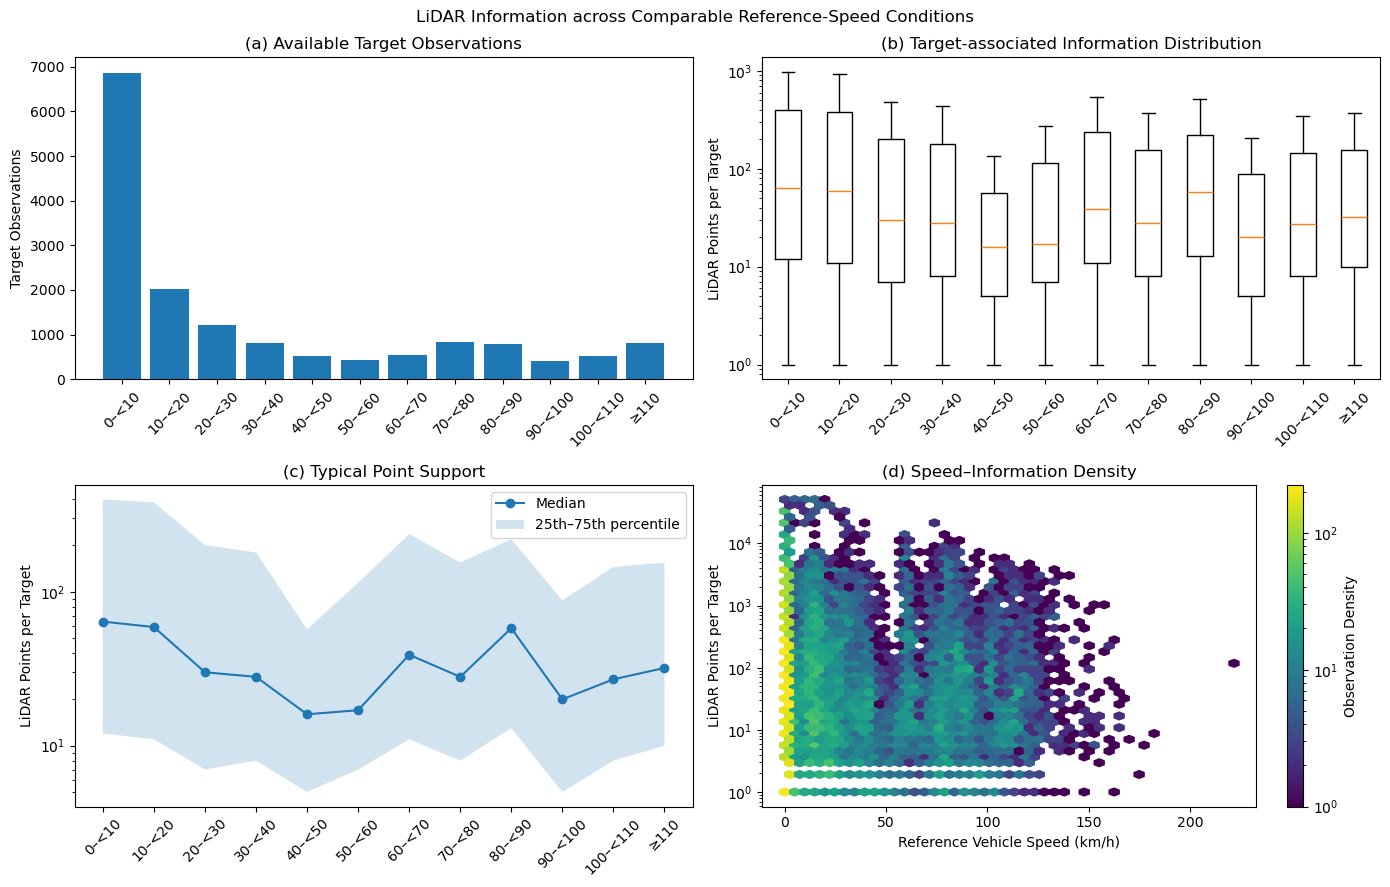

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(14, 9))

speed_categories = lidar_speed_df["speed_range_kmh"].cat.categories
x_labels = [str(x) for x in speed_categories]
plot_summary = lidar_speed_summary.reset_index()

# (a) Number of observations
axes[0, 0].bar(x_labels, plot_summary["Target_Observations"])
axes[0, 0].set_ylabel("Target Observations")
axes[0, 0].set_title("(a) Available Target Observations")

# (b) Point-support distributions
point_data = [
    lidar_speed_df.loc[
        lidar_speed_df["speed_range_kmh"] == speed_range, "lidar_point_count"
    ].dropna()
    for speed_range in speed_categories
]

axes[0, 1].boxplot(point_data, labels=x_labels, showfliers=False)
axes[0, 1].set_yscale("log")
axes[0, 1].set_ylabel("LiDAR Points per Target")
axes[0, 1].set_title("(b) Target-associated Information Distribution")

# (c) Median and interquartile range
x = np.arange(len(plot_summary))

axes[1, 0].plot(
    x,
    plot_summary["Median_LiDAR_Points"],
    marker="o",
    label="Median",
)

axes[1, 0].fill_between(
    x,
    plot_summary["P25_LiDAR_Points"],
    plot_summary["P75_LiDAR_Points"],
    alpha=0.2,
    label="25th–75th percentile",
)

axes[1, 0].set_yscale("log")
axes[1, 0].set_xticks(x)
axes[1, 0].set_xticklabels(x_labels, rotation=45)
axes[1, 0].set_ylabel("LiDAR Points per Target")
axes[1, 0].set_title("(c) Typical Point Support")
axes[1, 0].legend()

# (d) Continuous speed–information relationship
hb = axes[1, 1].hexbin(
    lidar_speed_df["speed_2d_kmh"],
    lidar_speed_df["lidar_point_count"],
    gridsize=45,
    yscale="log",
    bins="log",
    mincnt=1,
)

axes[1, 1].set_xlabel("Reference Vehicle Speed (km/h)")
axes[1, 1].set_ylabel("LiDAR Points per Target")
axes[1, 1].set_title("(d) Speed–Information Density")
fig.colorbar(hb, ax=axes[1, 1], label="Observation Density")

for ax in axes[0]:
    ax.tick_params(axis="x", rotation=45)

fig.suptitle("LiDAR Information across Comparable Reference-Speed Conditions")
plt.tight_layout()
plt.show()

The four panels provide complementary views of LiDAR information when the results are stratified by the common annotation-derived reference-speed ranges.

Panel (a) shows that the available observations are strongly concentrated in the lower-speed ranges. The 0–<10 km/h range contains substantially more target observations than any other range, while the higher-speed ranges contain much smaller samples. Results from sparsely populated speed ranges should therefore be interpreted with greater caution.

Panels (b) and (c) show that target-associated LiDAR point support varies across the reference-speed ranges, but the relationship is not monotonic. Typical point support decreases across several lower and intermediate-speed groups, but increases again in some higher-speed ranges. The wide interquartile ranges also show that substantial variation remains within each speed group.

Panel (d) supports the same conclusion without relying on predefined speed ranges. Observation density is highest at relatively low reference speeds, but LiDAR point support spans a wide range of values at similar vehicle speeds. There is therefore no single narrow relationship between reference speed and the amount of target-associated LiDAR information.

Together, these results indicate that reference speed alone does not explain the observed variation in LiDAR point support. Other factors, including target category, distance, orientation, occlusion, and sensor geometry, may also contribute. Since target-category differences were examined in Section 5.2, the following section focuses on target distance as an additional spatial factor.

### 5.4 Spatial Characteristics of LiDAR Information

The previous analysis showed substantial variation in target-associated LiDAR point support that could not be explained by reference vehicle speed alone.

Target distance is therefore examined as an additional spatial factor. For each annotated target, the target position is compared with the ego-vehicle position associated with the closest LiDAR keyframe. The 2D ground-plane distance is used:

$$
d_{2D}=\sqrt{(x_{target}-x_{ego})^2+(y_{target}-y_{ego})^2}.
$$

The relationship between target distance and LiDAR point support is then examined directly without introducing additional distance bins.


In [26]:
ego_poses = load_json(METADATA_ROOT / "ego_pose.json")
sample_data_records = load_json(METADATA_ROOT / "sample_data.json")

ego_pose_lookup = {x["token"]: x for x in ego_poses}
sample_data_lookup = {x["token"]: x for x in sample_data_records}
annotation_lookup = {x["token"]: x for x in annotations}
sample_timestamp_lookup = {x["token"]: x["timestamp"] for x in samples}

lidar_keyframes = sensor_data_df[
    (sensor_data_df["Modality"] == "LiDAR")
    & sensor_data_df["Is Key Frame"]
].copy()

lidar_keyframes["Sample Timestamp"] = lidar_keyframes["Sample Token"].map(
    sample_timestamp_lookup
)
lidar_keyframes["Sample Offset"] = (
    lidar_keyframes["Timestamp"] - lidar_keyframes["Sample Timestamp"]
).abs()

closest_idx = lidar_keyframes.groupby("Sample Token")["Sample Offset"].idxmin()
closest_lidar_keyframes = lidar_keyframes.loc[closest_idx].copy()

In [27]:
sample_ego_position = {}

for _, row in closest_lidar_keyframes.iterrows():
    sd = sample_data_lookup[row["Token"]]
    ego_pose = ego_pose_lookup[sd["ego_pose_token"]]
    sample_ego_position[row["Sample Token"]] = np.asarray(
        ego_pose["translation"], dtype=float
    )

spatial_records = []

for _, row in target_lidar_df.iterrows():
    ego_position = sample_ego_position.get(row["sample_token"])

    if ego_position is None:
        continue

    target_position = np.asarray(
        annotation_lookup[row["annotation_token"]]["translation"],
        dtype=float,
    )

    delta = target_position - ego_position

    spatial_records.append({
        "annotation_token": row["annotation_token"],
        "lidar_point_count": row["lidar_point_count"],
        "distance_2d_m": np.hypot(delta[0], delta[1]),
    })

lidar_spatial_df = pd.DataFrame(spatial_records)

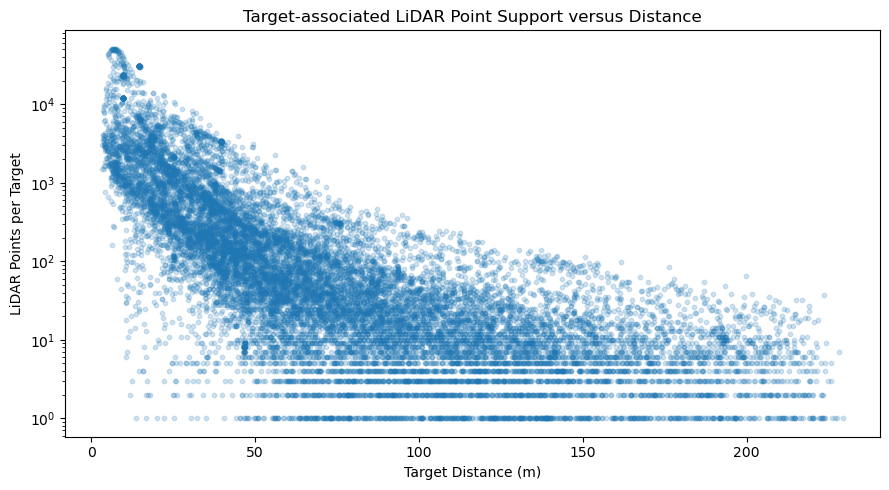

In [28]:
plt.figure(figsize=(9, 5))

plt.scatter(lidar_spatial_df["distance_2d_m"], lidar_spatial_df["lidar_point_count"], alpha=0.2, s=10)
plt.yscale("log")
plt.xlabel("Target Distance (m)")
plt.ylabel("LiDAR Points per Target")
plt.title("Target-associated LiDAR Point Support versus Distance")

plt.tight_layout()
plt.show()

Target-associated LiDAR point support decreases strongly as target distance increases. Nearby targets can contain several thousand LiDAR points, while more distant targets are generally supported by substantially fewer points. The spread in point counts is also large at shorter distances and becomes more concentrated at low point counts as distance increases.

This strong association with target distance shows that spatial distance is an important factor when interpreting the amount of LiDAR information available for a target. It also helps explain why the variation observed across the reference-speed ranges in Section 5.3 should not be attributed to reference speed alone.

### 5.5 LiDAR-derived 2D Velocity Outcome

The previous sections describe LiDAR information acquisition using target-associated point support. This section evaluates velocity as a separate measurable outcome.

LiDAR does not provide a direct velocity field. Target positions are instead estimated from raw target-associated LiDAR points in the global coordinate frame, and consecutive same-sensor target states are paired to derive 2D velocity. Annotation boxes are used only for target association, so the resulting quantity is treated as a LiDAR-derived velocity estimate rather than a direct sensor measurement.

In [29]:
calibrated_sensors = load_json(METADATA_ROOT / "calibrated_sensor.json")
calibrated_sensor_lookup = {x["token"]: x for x in calibrated_sensors}

lidar_keyframes = sensor_data_df[(sensor_data_df["Modality"] == "LiDAR") & sensor_data_df["Is Key Frame"]].copy()
lidar_target_states_df = build_lidar_target_states_df(
    target_lidar_df,
    annotations,
    lidar_keyframes,
    sample_data_lookup,
    ego_pose_lookup,
    calibrated_sensor_lookup,
    SENSOR_ROOT,
)
lidar_velocity_df = build_lidar_velocity_df(lidar_target_states_df, annotations,)

In [30]:
interval_key = ["start_annotation_token", "end_annotation_token"]

lidar_velocity_eval_df = (
    vehicle_reference_df[
        interval_key + ["speed_2d_mps", "speed_2d_kmh"]
    ]
    .merge(
        lidar_velocity_df[
            interval_key + ["lidar_speed_2d_mps"]
        ],
        on=interval_key,
        how="left",
        validate="one_to_one",
    )
)

lidar_velocity_eval_df["Absolute Speed Error"] = (
    lidar_velocity_eval_df["lidar_speed_2d_mps"]
    - lidar_velocity_eval_df["speed_2d_mps"]
).abs()

total_intervals = len(lidar_velocity_eval_df)
available_intervals = lidar_velocity_eval_df["lidar_speed_2d_mps"].notna().sum()

lidar_velocity_summary = pd.Series({
    "Reference Intervals": total_intervals,
    "LiDAR Velocity Estimates": available_intervals,
    "LiDAR Velocity Availability (%)": available_intervals / total_intervals * 100,
    "Median Absolute Error (m/s)": lidar_velocity_eval_df["Absolute Speed Error"].median(),
    "P75 Absolute Error (m/s)": lidar_velocity_eval_df["Absolute Speed Error"].quantile(0.75),
})

display(lidar_velocity_summary.round(3))

Reference Intervals                15743.000
LiDAR Velocity Estimates            8007.000
LiDAR Velocity Availability (%)       50.861
Median Absolute Error (m/s)            0.224
P75 Absolute Error (m/s)               0.553
dtype: float64

In [31]:
lidar_velocity_eval_df["speed_range_kmh"] = pd.cut(
    lidar_velocity_eval_df["speed_2d_kmh"],
    bins=speed_bins,
    labels=speed_labels,
    right=False,
    include_lowest=True,
)

lidar_velocity_speed_summary = (
    lidar_velocity_eval_df
    .groupby("speed_range_kmh", observed=False)
    .agg(
        Reference_Intervals=("speed_2d_mps", "size"),
        LiDAR_Estimates=("lidar_speed_2d_mps", "count"),
        Median_Abs_Error=("Absolute Speed Error", "median"),
        P75_Abs_Error=("Absolute Speed Error", lambda x: x.quantile(0.75)),
    )
)

lidar_velocity_speed_summary["LiDAR Availability (%)"] = (
    lidar_velocity_speed_summary["LiDAR_Estimates"]
    / lidar_velocity_speed_summary["Reference_Intervals"]
    * 100
)

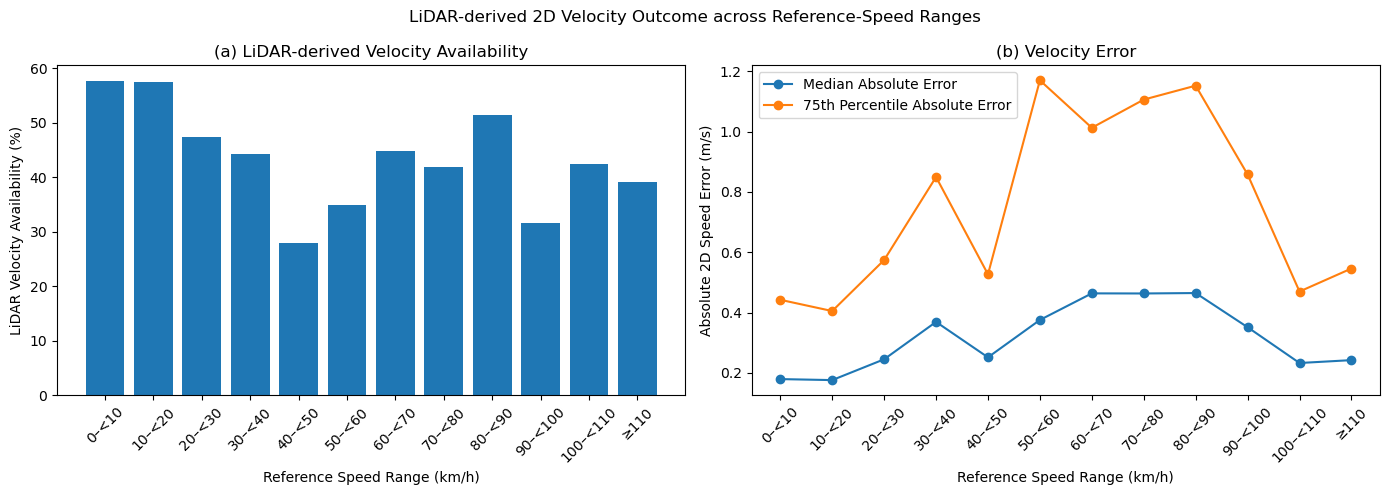

In [32]:
plot_data = lidar_velocity_speed_summary.reset_index()
x = np.arange(len(plot_data))
x_labels = plot_data["speed_range_kmh"].astype(str)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(x_labels, plot_data["LiDAR Availability (%)"])
axes[0].set_xlabel("Reference Speed Range (km/h)")
axes[0].set_ylabel("LiDAR Velocity Availability (%)")
axes[0].set_title("(a) LiDAR-derived Velocity Availability")
axes[0].tick_params(axis="x", rotation=45)

axes[1].plot(
    x, plot_data["Median_Abs_Error"],
    marker="o", label="Median Absolute Error"
)
axes[1].plot(
    x, plot_data["P75_Abs_Error"],
    marker="o", label="75th Percentile Absolute Error"
)

axes[1].set_xticks(x)
axes[1].set_xticklabels(x_labels, rotation=45)
axes[1].set_xlabel("Reference Speed Range (km/h)")
axes[1].set_ylabel("Absolute 2D Speed Error (m/s)")
axes[1].set_title("(b) Velocity Error")
axes[1].legend()

fig.suptitle("LiDAR-derived 2D Velocity Outcome across Reference-Speed Ranges")
plt.tight_layout()
plt.show()

### 5.6 Summary

TruckScenes LiDAR provides spatial coordinates, intensity, and point-level temporal information, but it does not contain a direct vehicle-velocity field. LiDAR information acquisition and LiDAR-derived velocity are therefore evaluated separately in this report.

Earlier validation showed that direct raw point-in-box counting did not exactly reproduce the dataset-provided `num_lidar_pts` values. The dataset-provided `num_lidar_pts` field is therefore retained as the target-associated LiDAR point-support metric for the information-acquisition analysis.

Target-associated LiDAR information is highly variable and strongly right-skewed. When stratified by the common annotation-derived reference-speed ranges, both target availability and LiDAR point support vary substantially, but neither follows a simple monotonic relationship with reference speed. Spatial analysis shows a clearer association with target distance, with target-associated LiDAR point support generally decreasing strongly as distance increases.

Raw target-associated LiDAR points are also used separately to estimate target positions and derive 2D velocity from consecutive same-sensor observations. Of the 15,743 annotation-derived reference intervals, 8,007 produce a LiDAR-derived velocity estimate, corresponding to an overall availability of 50.86%. For these available estimates, the median absolute 2D speed error is 0.224 m/s and the 75th-percentile absolute error is 0.553 m/s.

The LiDAR results therefore distinguish information acquisition from velocity performance. The `num_lidar_pts` measure describes the amount of target-associated spatial information available, while derived-velocity availability and error describe how effectively raw LiDAR observations can support motion estimation. LiDAR-derived velocity is an estimated outcome and is not interpreted as a direct velocity measurement provided by the sensor. LiDAR point counts are also not treated as directly equivalent to RADAR return counts.

## 6. Camera Analysis

This section evaluates Camera information acquisition for target-motion analysis.

Camera does not provide a direct vehicle-velocity outcome in the current analysis. Its contribution is therefore evaluated primarily through the availability and usefulness of visual target information.

The annotation-derived 2D ground-plane speed is used only to stratify Camera information-acquisition results under comparable vehicle-speed conditions.

### 6.1 Camera Information Type

Camera provides image-based visual information about target vehicles but does not contain a direct velocity field. No Camera-derived velocity outcome is calculated in this analysis.

For efficiency analysis, a target is considered to have Camera information when its annotated 3D bounding box is visible within at least one keyframe Camera view. The number of supporting Camera views is retained as an additional measure of visual support.

Camera is therefore evaluated through visual-information acquisition rather than direct velocity measurement.

### 6.2 Overall Camera Information Acquisition

Overall Camera efficiency is first examined through target-level visual-information availability.

Camera information availability describes how consistently annotated targets receive visual support, while the number of supporting Camera views provides additional information about the amount of visual support available for each target observation.

These measures describe information-acquisition efficiency rather than vehicle velocity.

In [44]:
truckscenes = TruckScenes(version=VERSION, dataroot=str(DATA_ROOT), verbose=False)
camera_keyframes = sensor_data_df[(sensor_data_df["Modality"] == "Camera") & sensor_data_df["Is Key Frame"]].copy()
camera_view_df, target_camera_df = build_camera_target_df(truckscenes, vehicle_annotation_df, camera_keyframes)

c:\Users\HUAWEI\anaconda3\Lib\site-packages\truckscenes\truckscenes.py:93: UserWarning: The visualization dependencies are not installed on your system! Run 'pip install "truckscenes-devkit[all]"'.
  warnings.warn('''The visualization dependencies are not installed on your system! '''


In [46]:
camera_summary = pd.DataFrame({
    "Metric": ["Targets with Camera information", "Camera information availability (%)", "Median supporting Camera views"],
    "Value": [
        target_camera_df["has_camera_information"].sum(),
        target_camera_df["has_camera_information"].mean() * 100,
        target_camera_df.loc[target_camera_df["has_camera_information"], "camera_view_count"].median()
    ]
})

display(camera_summary.round(2))

,Metric,Value
0,Targets with Camera information,16217.00
1,Camera information availability (%),98.28
2,Median supporting Camera views,1.00


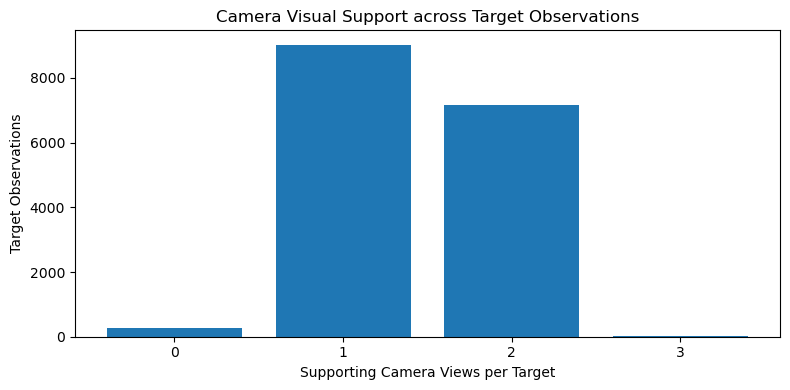

In [47]:
camera_view_counts = target_camera_df["camera_view_count"].value_counts().sort_index()

plt.figure(figsize=(8, 4))
plt.bar(camera_view_counts.index.astype(str), camera_view_counts.values)
plt.xlabel("Supporting Camera Views per Target")
plt.ylabel("Target Observations")
plt.title("Camera Visual Support across Target Observations")
plt.tight_layout()
plt.show()

Camera visual information was available for 16,217 of the 16,501 target observations, corresponding to an overall availability of 98.28%.

Most target observations were supported by one or two Camera views, while observations without Camera support were uncommon. The median number of supporting Camera views was one.

This indicates that Camera provides highly available visual target information in the mini dataset, although most individual targets are observed from only a limited number of Camera viewpoints.

### 6.3 Camera Information Stratified by Reference Speed

Camera information availability is stratified using the same annotation-derived reference-speed ranges used throughout the analysis.

Reference speed is used only as a stratification variable and is not treated as a Camera velocity measurement or efficiency metric. The comparison examines whether Camera information-acquisition consistency changes under different vehicle-speed conditions.

In [48]:
camera_speed_df = target_camera_df.merge(
    vehicle_reference_df[["start_annotation_token", "speed_2d_mps"]],
    left_on="annotation_token", right_on="start_annotation_token", how="left", validate="one_to_one"
).dropna(subset=["speed_2d_mps"]).copy()

camera_speed_df["speed_2d_kmh"] = camera_speed_df["speed_2d_mps"] * 3.6
camera_speed_df["speed_range_kmh"] = pd.cut(camera_speed_df["speed_2d_kmh"], bins=speed_bins, labels=speed_labels, right=False, include_lowest=True)

In [50]:
camera_speed_summary = (
    camera_speed_df
    .groupby("speed_range_kmh", observed=False)
    .agg(
        Target_Observations=("annotation_token", "size"),
        Camera_Supported=("has_camera_information", "sum"),
        Median_Camera_Views=("camera_view_count", "median"),
    )
)

camera_speed_summary["Camera Availability (%)"] = (
    camera_speed_summary["Camera_Supported"]
    / camera_speed_summary["Target_Observations"]
    * 100
)

display(camera_speed_summary.round(2))

,Target_Observations,Camera_Supported,Median_Camera_Views,Camera Availability (%)
speed_range_kmh,,,,
0–<10,6870,6703,1.0,97.57
10–<20,2028,1993,1.0,98.27
20–<30,1211,1188,1.0,98.10
30–<40,799,786,1.0,98.37
40–<50,510,502,1.0,98.43
50–<60,424,423,2.0,99.76
60–<70,542,542,1.0,100.00
70–<80,823,810,1.0,98.42
80–<90,797,794,1.0,99.62


Camera information availability remained consistently high across all reference-speed ranges, ranging from 97.57% to 100%.

No clear reduction in Camera information availability was observed as reference speed increased. The differences between speed ranges were small relative to the consistently high overall availability.

Therefore, within the TruckScenes mini dataset, vehicle-speed grouping did not reveal a substantial change in whether annotated vehicle targets were visually supported by the Camera system.

### 6.4 Camera Visibility Characteristics

Information availability alone does not indicate how useful the available visual information is.

TruckScenes provides an annotation-level visibility measure describing target visibility conditions. Visibility is therefore used as a Camera-specific indicator of the usefulness of the acquired visual information.

This complements Camera availability: availability describes whether visual information is acquired, while visibility provides context about the quality of that information.

In [ ]:
visibility_records = load_json(METADATA_ROOT / "visibility.json")
visibility_lookup = {record["token"]: record["level"] for record in visibility_records}
annotation_visibility = {annotation["token"]: visibility_lookup.get(annotation.get("visibility_token")) for annotation in annotations}
target_camera_df["visibility_level"] = target_camera_df["annotation_token"].map(annotation_visibility)

In [54]:
visibility_summary = target_camera_df["visibility_level"].value_counts().sort_index().to_frame("Target_Observations")
visibility_summary["Percentage"] = visibility_summary["Target_Observations"] / len(target_camera_df) * 100

display(visibility_summary.round(2))

,Target_Observations,Percentage
visibility_level,,
1,5696,34.52
2,1680,10.18
3,1431,8.67
4,7694,46.63


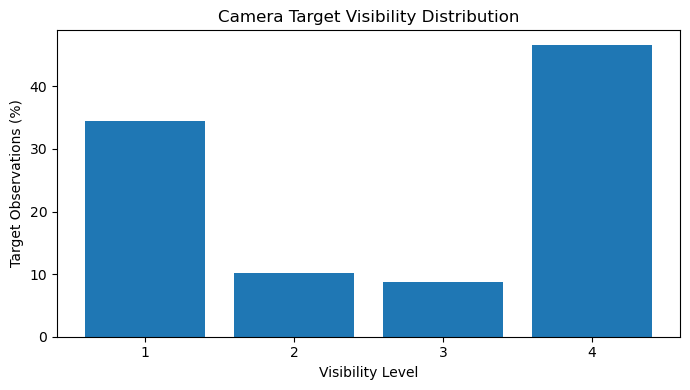

In [58]:
plt.figure(figsize=(7, 4))
plt.bar(visibility_summary.index.astype(str), visibility_summary["Percentage"])
plt.xlabel("Visibility Level")
plt.ylabel("Target Observations (%)")
plt.title("Camera Target Visibility Distribution")
plt.tight_layout()
plt.show()

The visibility distribution was not uniform across the four levels.

Visibility level 4 was the most common, representing 46.63% of target observations, followed by level 1 at 34.52%. Levels 2 and 3 accounted for smaller proportions of the dataset.

This result shows that Camera target observations span different visibility conditions rather than being concentrated in a single visibility level. Visibility therefore provides additional Camera-specific context beyond the simple presence or absence of Camera information.

### 6.5 Summary

Camera does not provide a direct vehicle-velocity outcome in the current analysis and is therefore evaluated through visual-information acquisition efficiency.

Camera information was available for 16,217 of the 16,501 target observations, corresponding to an overall availability of 98.28%. This indicates consistently high visual target support in the mini dataset. Most supported targets were visible in one or two Camera views.

When stratified by the common annotation-derived reference-speed ranges, Camera information availability remained between 97.57% and 100%. Reference speed is used only for stratification, and the results indicate that Camera information availability remained broadly consistent across the observed vehicle-speed conditions.

The visibility distribution provides additional information about the usefulness of the acquired Camera observations by showing that targets were observed under a range of visibility conditions.

Overall, Camera efficiency is characterised through the consistency and usefulness of visual-information acquisition rather than through a direct velocity outcome.

## 7. Cross-Sensor Comparison

This section brings together the RADAR, LiDAR, and Camera results developed in the previous sections.

Velocity and sensor-information efficiency are treated as separate evaluation dimensions. Velocity is an outcome metric, while the annotation-derived reference-speed ranges are used only for stratification. Efficiency describes how consistently, frequently, and usefully sensor information is acquired.

RADAR and LiDAR are compared directly where both produce a 2D velocity estimate. Camera is not included in the velocity-accuracy comparison because no Camera-derived velocity outcome is calculated in this analysis.

All three sensor modalities are included in the information-acquisition efficiency comparison.

### 7.1 Velocity Outcome Comparison

RADAR and LiDAR velocity outcomes are compared using the common annotation-derived reference intervals.

Velocity-estimation availability is measured across all valid reference intervals. Direct accuracy comparison is then restricted to matched intervals where both RADAR and LiDAR estimates are available, ensuring that the two methods are evaluated under the same target-motion observations.

The primary accuracy measure is the absolute difference between the sensor-derived 2D speed and the annotation-derived 2D reference speed.

In [69]:
comparison_df = build_velocity_comparison_df(vehicle_reference_df, radar_stable_velocity_df, lidar_velocity_df)
comparison_df["radar_abs_error_2d_mps"] = (comparison_df["radar_speed_2d_mps"] - comparison_df["speed_2d_mps"]).abs()
comparison_df["lidar_abs_error_2d_mps"] = (comparison_df["lidar_speed_2d_mps"] - comparison_df["speed_2d_mps"]).abs()
matched_velocity_df = comparison_df[comparison_df["radar_velocity_available"] & comparison_df["lidar_velocity_available"]].copy()

In [70]:
velocity_comparison_summary = pd.DataFrame({
    "Velocity Availability (%)": [
        comparison_df["radar_velocity_available"].mean() * 100,
        comparison_df["lidar_velocity_available"].mean() * 100
    ],
    "Matched Intervals": [len(matched_velocity_df), len(matched_velocity_df)],
    "Matched Median Abs. Error (m/s)": [
        matched_velocity_df["radar_abs_error_2d_mps"].median(),
        matched_velocity_df["lidar_abs_error_2d_mps"].median()
    ],
    "Matched P90 Abs. Error (m/s)": [
        matched_velocity_df["radar_abs_error_2d_mps"].quantile(0.90),
        matched_velocity_df["lidar_abs_error_2d_mps"].quantile(0.90)
    ]
}, index=["RADAR", "LiDAR"])

display(velocity_comparison_summary.round(3))

,Velocity Availability (%),Matched Intervals,Matched Median Abs. Error (m/s),Matched P90 Abs. Error (m/s)
RADAR,19.158,2899,0.266,9.558
LiDAR,50.861,2899,0.263,1.437


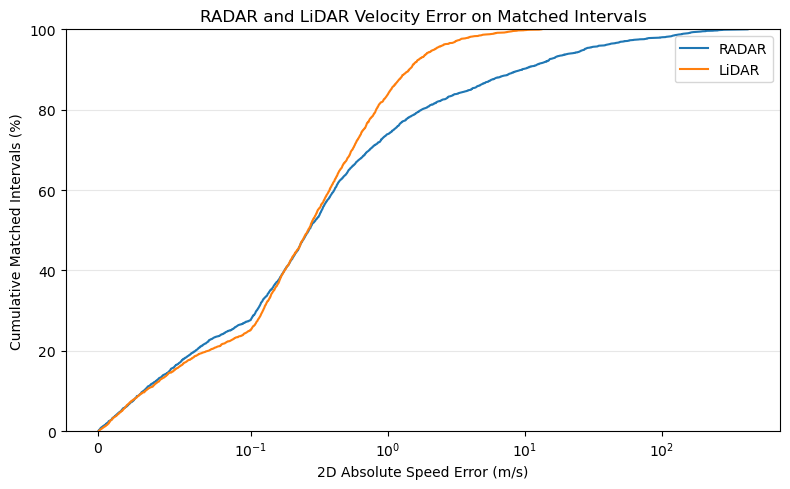

In [71]:
fig, ax = plt.subplots(figsize=(8, 5))

for column, label in [("radar_abs_error_2d_mps", "RADAR"), ("lidar_abs_error_2d_mps", "LiDAR")]:
    errors = np.sort(matched_velocity_df[column].dropna().to_numpy())
    ecdf = np.arange(1, len(errors) + 1) / len(errors) * 100
    ax.plot(errors, ecdf, label=label)

ax.set_xscale("symlog", linthresh=0.1)
ax.set_xlabel("2D Absolute Speed Error (m/s)")
ax.set_ylabel("Cumulative Matched Intervals (%)")
ax.set_title("RADAR and LiDAR Velocity Error on Matched Intervals")
ax.set_ylim(0, 100)
ax.legend()
ax.grid(axis="y", alpha=0.3)
plt.tight_layout()
plt.show()

The matched comparison isolates velocity behaviour under the same reference intervals and therefore provides a fairer comparison than separate single-sensor summaries.

The cumulative error distributions show that RADAR and LiDAR have similar behaviour at very small absolute errors, but their distributions diverge more clearly at larger errors. LiDAR reaches higher cumulative percentages earlier across much of the higher-error range, indicating a more stable upper error distribution on the matched intervals.

These results suggest that the typical matched velocity accuracy of RADAR and LiDAR is similar at low error levels, while LiDAR produces fewer large-error cases. Camera is excluded from this comparison because no Camera-derived velocity outcome is calculated in the current analysis.

### 7.2 Information-acquisition Efficiency Comparison

Sensor-information efficiency is compared across RADAR, LiDAR, and Camera using two common numerical dimensions:

- **Consistency:** the proportion of annotated vehicle targets for which the sensor provides target-related information.
- **Frequency:** the approximate native observation frequency derived from the sensor timestamps.

The usefulness of the acquired information is considered separately because the three modalities provide fundamentally different information types. RADAR returns, LiDAR points, and Camera views are therefore not treated as equivalent units and are not combined into a single efficiency score.

In [72]:
radar_supported = set(target_radar_df["annotation_token"])
lidar_supported = set(target_lidar_df.loc[target_lidar_df["lidar_point_count"] > 0, "annotation_token"])
camera_supported = set(target_camera_df.loc[target_camera_df["has_camera_information"], "annotation_token"])

target_availability = {
    "RADAR": vehicle_annotation_df["annotation_token"].isin(radar_supported).mean() * 100,
    "LiDAR": vehicle_annotation_df["annotation_token"].isin(lidar_supported).mean() * 100,
    "Camera": vehicle_annotation_df["annotation_token"].isin(camera_supported).mean() * 100
}

In [73]:
sampling_intervals = get_sampling_intervals(sensor_data_df)
sampling_summary = get_sampling_interval_summary(sampling_intervals)
_, modality_frequency = get_frequency_summary(sampling_summary)

sensor_order = ["RADAR", "LiDAR", "Camera"]

efficiency_summary = pd.DataFrame({
    "Target Information Availability (%)": [target_availability[sensor] for sensor in sensor_order],
    "Approx. Native Frequency (Hz)": [modality_frequency.loc[sensor, "Median_Frequency_Hz"] for sensor in sensor_order]
}, index=sensor_order)

display(efficiency_summary.round(2))

,Target Information Availability (%),Approx. Native Frequency (Hz)
RADAR,58.11,19.5
LiDAR,100.00,10.0
Camera,98.28,10.0


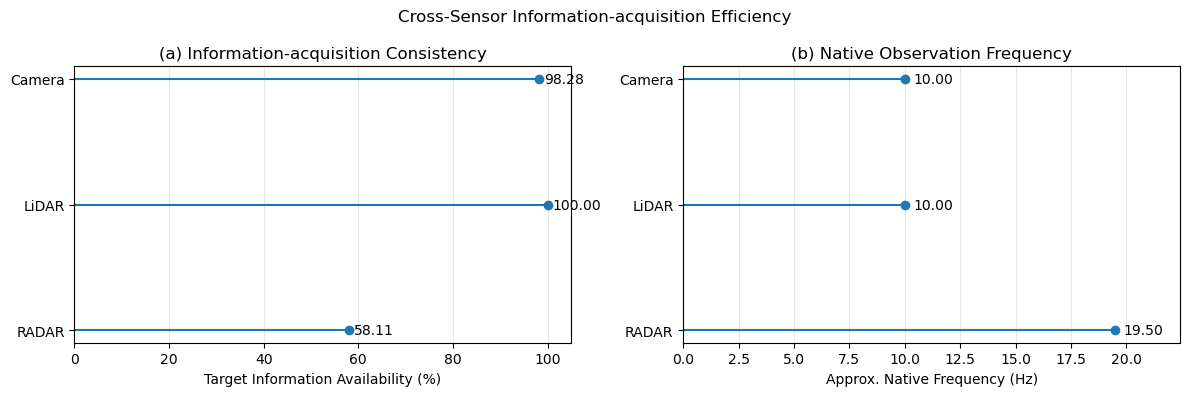

In [74]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
y = np.arange(len(sensor_order))

availability = efficiency_summary["Target Information Availability (%)"].reindex(sensor_order).to_numpy()
frequency = efficiency_summary["Approx. Native Frequency (Hz)"].reindex(sensor_order).to_numpy()

axes[0].hlines(y, 0, availability)
axes[0].plot(availability, y, "o")
axes[0].set_yticks(y)
axes[0].set_yticklabels(sensor_order)
axes[0].set_xlim(0, 105)
axes[0].set_xlabel("Target Information Availability (%)")
axes[0].set_title("(a) Information-acquisition Consistency")
axes[0].grid(axis="x", alpha=0.3)

for i, v in enumerate(availability):
    axes[0].text(v + 1, i, f"{v:.2f}", va="center")

axes[1].hlines(y, 0, frequency)
axes[1].plot(frequency, y, "o")
axes[1].set_yticks(y)
axes[1].set_yticklabels(sensor_order)
axes[1].set_xlim(0, max(frequency) * 1.15)
axes[1].set_xlabel("Approx. Native Frequency (Hz)")
axes[1].set_title("(b) Native Observation Frequency")
axes[1].grid(axis="x", alpha=0.3)

for i, v in enumerate(frequency):
    axes[1].text(v + max(frequency) * 0.02, i, f"{v:.2f}", va="center")

fig.suptitle("Cross-Sensor Information-acquisition Efficiency")
plt.tight_layout()
plt.show()

The efficiency comparison shows that the three modalities differ across consistency and frequency.

RADAR has the highest native observation frequency at approximately 19.5 Hz, but its target-information availability is substantially lower at 58.11%. In contrast, LiDAR and Camera both operate at approximately 10 Hz while maintaining much higher target-information availability, at 100.00% and 98.28% respectively.

These results show that more frequent observations do not necessarily imply more consistent target support. Frequency and availability therefore capture different aspects of sensor-information acquisition efficiency and should be interpreted separately.

The usefulness of the acquired information cannot be represented by a single common numerical quantity because each modality provides a different type of sensor information.

| Sensor | Useful target information | Velocity role in the current analysis |
|---|---|---|
| RADAR | Target-associated returns with direct relative-velocity information | Supports ego-compensated 2D velocity reconstruction |
| LiDAR | Dense spatial point support and target geometry | Supports velocity estimation from consecutive target positions |
| Camera | Visual target support and target visibility | No Camera-derived velocity outcome is calculated |

The sensor-specific information quantities are therefore interpreted within each modality rather than directly compared as equivalent units.

### 7.3 Overall Cross-Sensor Interpretation

The cross-sensor comparison shows that velocity performance and information-acquisition efficiency represent different dimensions of sensor behaviour.

RADAR and LiDAR both support a derived 2D velocity outcome and can therefore be compared directly on matched reference intervals. Their matched error distributions show that both sensors can achieve low absolute velocity error, but LiDAR exhibits a more stable upper error distribution, with fewer large-error cases than RADAR.

Information-acquisition efficiency is broader than velocity performance. Target-information availability describes how consistently each sensor provides target-related information, while native observation frequency describes how frequently sensor observations are acquired. The usefulness of this information remains sensor-specific: RADAR provides velocity-related returns, LiDAR provides dense spatial information, and Camera provides visual and visibility information.

The results also show that a higher acquisition frequency does not necessarily imply higher target-information availability. RADAR operates at the highest native frequency but has the lowest target-information availability, while LiDAR and Camera operate at lower frequency but provide much more consistent target support.

These dimensions are intentionally not combined into a single efficiency score. The three sensors should therefore be interpreted as providing complementary information rather than being ranked using one overall performance number.

## 8. Summary and Limitations

This analysis compared RADAR, LiDAR, and Camera information in TruckScenes from two separate perspectives: vehicle-velocity outcomes and sensor-information acquisition efficiency.

Velocity was treated as an outcome metric, while annotation-derived reference-speed ranges were used only for stratification. Efficiency was evaluated through how consistently, frequently, and usefully sensor information was acquired.

The following sections summarise the main findings and the limitations of the current analysis.

### 8.1 Key Findings

The annotation-derived 2D ground-plane speed provided a common motion reference for the sensor analyses. The same reference-speed ranges were applied across RADAR, LiDAR, and Camera so that sensor behaviour could be examined under comparable vehicle-speed conditions.

RADAR provided direct point-level velocity-related information and operated at the highest approximate native observation frequency, at 19.5 Hz. However, target-information availability was lower than for the other modalities, at 58.11%. RADAR velocity estimates also showed a heavier upper error tail in the matched comparison, indicating that large errors occurred more frequently than for LiDAR.

LiDAR did not contain a direct velocity field, but its spatial target information supported derived vehicle-motion estimation. Target-information availability reached 100% in the current analysis, with an approximate native observation frequency of 10 Hz. On matched reference intervals, LiDAR showed a more stable upper velocity-error distribution than RADAR.

Camera was evaluated through visual-information acquisition rather than through a direct velocity outcome. Visual target information was available for 98.28% of target observations, also at an approximate native frequency of 10 Hz. Camera availability remained consistently high across the reference-speed ranges, while the dataset-provided visibility levels showed that the usefulness of visual information varied across target observations.

Overall, the results show that the three modalities provide different strengths. RADAR provides direct velocity-related information at a higher observation frequency, LiDAR provides highly consistent spatial target support, and Camera provides highly available visual and visibility information. No single sensor was therefore identified as universally superior across both velocity and efficiency dimensions.

### 8.2 Limitations

The analysis was conducted using TruckScenes v1.2-mini rather than the complete dataset. The results therefore describe the sensor behaviour observed in the mini subset and should not be interpreted as representative of all TruckScenes driving conditions. The number of observations also differs across reference-speed ranges, particularly at higher speeds, which limits direct comparison between some speed groups.

The reference velocity was derived from consecutive object annotations rather than from an independent high-frequency ground-truth velocity sensor. It represents average object motion between annotation keyframes and is therefore used as a common analytical reference rather than as a perfect instantaneous ground truth. The 2D ground-plane speed was used as the primary reference, while vertical motion was not a primary focus of the comparison.

The three sensor modalities also provide fundamentally different information. RADAR returns, LiDAR points, and Camera observations cannot be directly interpreted as equivalent units of useful information. For this reason, efficiency was separated into consistency, frequency, and sensor-specific usefulness rather than combined into a single numerical score.

The native observation frequency used in the efficiency comparison was derived from sensor timestamps. It represents information-acquisition frequency and does not measure computational processing time, latency, bandwidth, or the runtime efficiency of downstream perception algorithms.

Finally, Camera was evaluated through target visibility and visual-information availability rather than through image-based velocity estimation. Factors such as illumination, weather, motion blur, image quality, and learned visual detection performance were outside the current scope. Similarly, the analysis did not attempt to combine the three sensor modalities through sensor fusion.

### 8.3 Conclusion

The analysis demonstrates that velocity performance and sensor-information acquisition efficiency should be treated as separate dimensions when comparing heterogeneous autonomous-driving sensors.

RADAR and LiDAR can both support vehicle-motion estimation, but they differ in information availability, observation frequency, and the distribution of velocity-estimation error. Camera contributes a different form of information and is more appropriately evaluated through visual availability and visibility in the current analysis.

The reference-speed stratification did not serve as an efficiency measure itself; instead, it provided a common basis for examining whether sensor behaviour changed under different vehicle-motion conditions.

Within TruckScenes v1.2-mini, the results indicate a complementary relationship between the three modalities: RADAR provides higher-frequency velocity-related information, LiDAR provides consistent spatial information and stable derived velocity outcomes, and Camera provides highly available visual target information.

These results support evaluating RADAR, LiDAR, and Camera according to their different information characteristics rather than reducing their performance to a single sensor ranking.